<h1 style="text-align: center; font-family: 'menlo'; color: #9b1515; font-size:50px;">
  <span style="background-color: #e6a3a3; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Dark current: the ideal case
  </span>
</h1>

In [1]:
import numpy as np 
from scipy import stats

%matplotlib inline
from matplotlib import pyplot as plt
from image_sim import dark_current, read_noise

# A dark frame measures dark current

Recall that dark current refers to counts (electrons) generated in a pixel because an electron in the pixel happens to have enough energy to “break free” and register as a count. The distribution of electron thermal energies in a pixel follows a [Maxwell-Boltzmann distribution](https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution) in which most electrons have energy around $kT$, where $T$ is the temperature of the sensor and $k$ is the Boltzmann constant. There is a distribution of energies, though, and occasionally an electron will be high energy enough to jump to the conducting band in the chip, registering the same as an electron excited by a photon. Since the Maxwell-Boltzmann distribution depends on temperature, the rate at which dark current appears in a pixel is also expected to depend on temperature.

A **dark frame** (also called a **dark image**) is an image taken with your camera with the shutter closed. It is the sum of the bias level of your camera, the readout noise, and the dark current.

You measure the dark current in your camera by taking dark frames.

# Convenience functions

A couple of functions that will be reused a few times in this notebook are defined below.

**A function to generate dark frames**

This function generates a set of dark frames. It will be used several times below.

In [4]:
def generate_dark_frames(n_frames, 
                         dark_rate=0, 
                         noise=0,
                         gain=1,
                         exposure=10,
                         image_size=500):
    
    base_image = np.zeros([image_size, image_size])
    darks = np.zeros([n_frames, image_size, image_size])
    
    for n in range(n_images):
        darks[n] = dark_current(base_image, dark_rate, exposure, gain=gain, hot_pixels=False)
        if noise > 0:
            darks[n] = darks[n] + read_noise(base_image, noise, gain=gain)

    return darks

**A function to plot the distribution of dark counts**

The function below plots the:

In [5]:
def plot_dark_with_distributions(image, rn, dark_rate, 
                                 n_images=1,
                                 exposure=1,
                                 gain=1,
                                 show_poisson=True, 
                                 show_gaussian=True):
    """
    Plot the distribution of dark pixel values, optionally overplotting the expected Poisson and
    normal distributions corresponding to dark current only or read noise only.
    
    Parameters
    ----------
    
    image : numpy array
        Dark frame to histogram.
    
    rn : float
        The read noise, in electrons.
        
    dark_rate : float
        The dark current in electrons/sec/pixel.
    
    n_images : float, optional
        If the image is formed from the average of some number of dark frames then 
        the resulting Poisson distribution depends on the number of images, as does the 
        expected standard deviation of the Gaussian.
        
    exposure : float
        Exposure time, in seconds.
        
    gain : float, optional
        Gain of the camera, in electron/ADU.
        
    show_poisson : bool, optional
        If ``True``, overplot a Poisson distribution with mean equal to the expected dark
        counts for the number of images.
    
    show_gaussian : bool, optional
        If ``True``, overplot a normal distribution with mean equal to the expected dark
        counts and standard deviation equal to the read noise, scaled as appropiate for 
        the number of images.
    """
    
    h = plt.hist(image.flatten(), bins=20, align='mid', 
                 density=True, label="Dark frame");

    bins = h[1]
    
    expected_mean_dark = dark_rate * exposure / gain
    
    pois = stats.poisson(expected_mean_dark * n_images)

    pois_x = np.arange(0, 300, 1)

    new_area = np.sum(1/n_images * pois.pmf(pois_x))

    if show_poisson:
        plt.plot(pois_x / n_images, pois.pmf(pois_x) / new_area, 
                 label="Poisson dsitribution, mean of {:5.2f} counts".format(expected_mean_dark)) 

    if show_gaussian:
        # The expected width of the Gaussian depends on the number of images.
        expected_scale = rn / gain * np.sqrt(n_images)
        
        # Mean value is same as for the Poisson distribution 
        expected_mean = expected_mean_dark * n_images
        gauss = stats.norm(loc=expected_mean, scale=expected_scale)
        
        gauss_x = np.linspace(expected_mean - 5 * expected_scale,
                              expected_mean + 5 * expected_scale,
                              num=100)
        plt.plot(gauss_x / n_images, gauss.pdf(gauss_x) * n_images, label='Gaussian, standard dev is read noise in counts') 
        
    plt.xlabel("Dark counts in {} sec exposure".format(exposure))
    plt.ylabel("Fraction of pixels (area normalized to 1)")
    plt.grid()
    plt.legend()

# Dark current theory

The expected signal in a dark frame exposure of time $t$ is proportional to $t$. If we call the dark electrons in an exposure $d_e (t)$ and the dark current $d_c (T)$, where $T$ is the temperature, then

$d_e (t) = d_c (T)t$

For liquid-cooled cameras, particularly ones cooled by liquid nitrogen, the operating temperature doesn’t change. For thermoelectrically-cooled cameras you are able to set the desired operating temperature. As a result, you should be able to ignore the temperature dependence of the dark current.

The thermoelectric coolers can usually cool by some fixed amount below the ambient temperature. Though in principle you could choose to always cool by the same fixed amount, like $50°C$ below the ambient temperature, there is an advantage to always running your camera at the same temperature: dark frames taken on one date are potentially useful on another date. If the operating temperature varies then you need to make sure to take dark frames every time you observe unless you carefully characterize the temperature dependence of your dark current.

It will turn out that for practical reasons — not all pixels in your camera have the same dark current — it is usually best to take dark frames every time you observe anyway. 

*A principal conclusão prática é: se mantém a temperatura constante (com um sistema de resfriamento), a corrente de escuro se torna um valor fixo e previsível, que escala linearmente com o tempo de exposição. Por isso, eles sugerem que, na prática, se pode ignorar a dependência da temperatura desde que a câmera esteja estabilizada termicamente.*

# Illustration with dark current only

For the purposes of illustrating some of the properties of dark current and dark frames, we’ll generate some simulated images in which the counts are due to dark current alone. We’ll use these values:

- Dark current is $d_c (T) = 0.1e^-$ /pixel/sec
- Gain is $g = 1.5e^-$/ADU
- Read noise is 0 $e^-$

In [7]:
dark_rate = 0.1
gain = 1.5
read_noise_electrons = 0

## Dark current is a random process

The dark counts in a dark frame are counts and so they follow a <u>Poisson distribution.</u> The plot below shows the dark current in a number of <u>randomly</u> chosen pixels in 20 different simulated images each with exposure time 100 sec. Note that the counts vary from image to image but that the average is very close to the expected value.

The expected value of the dark counts for this image is $d_e(t)/g=6.67$ counts.

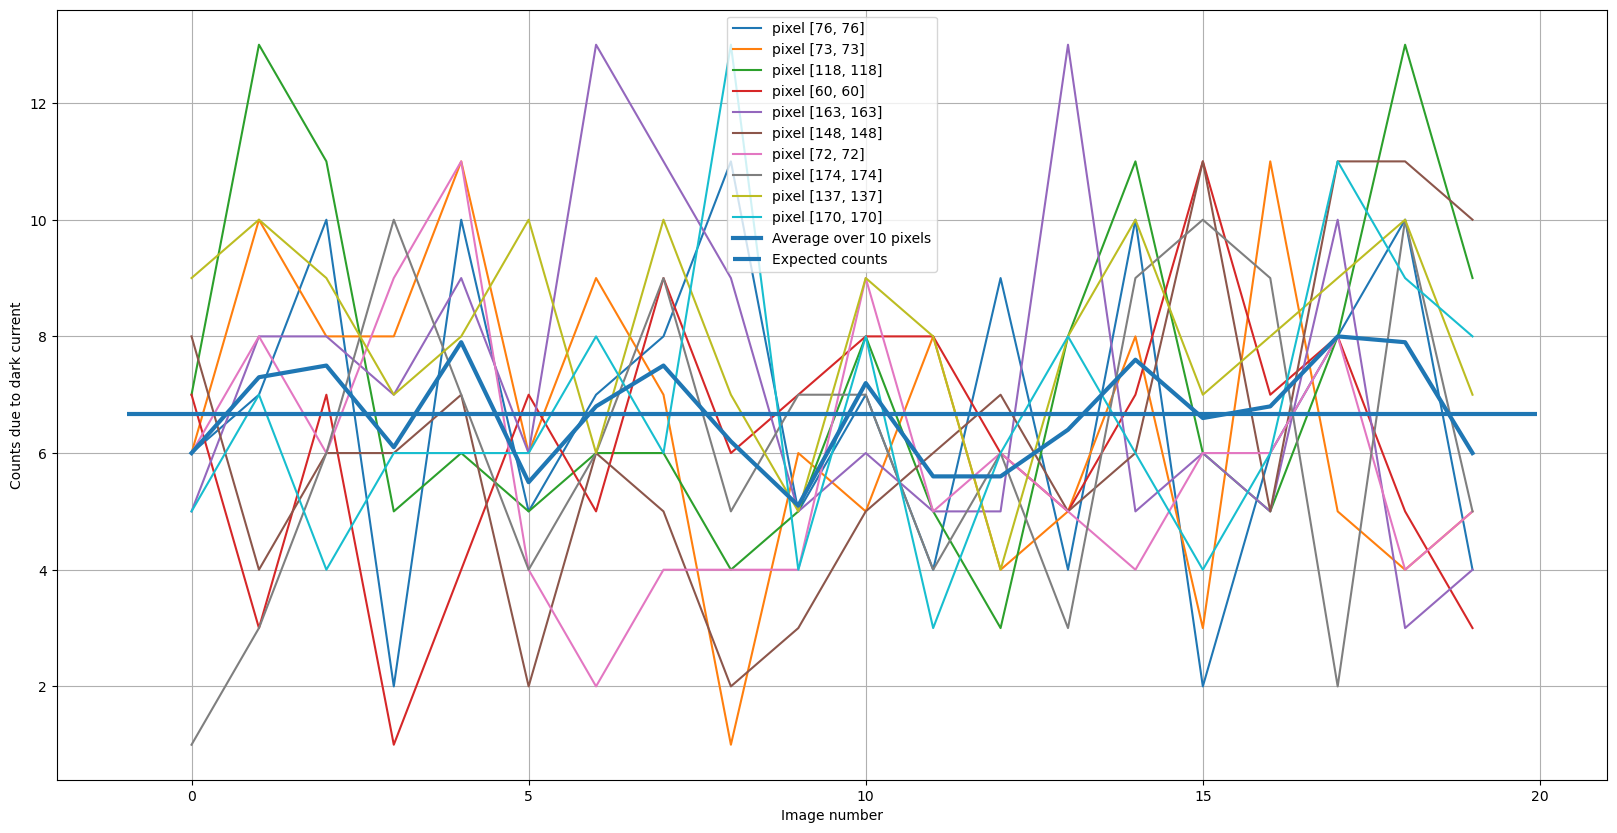

In [13]:
exposure = 100
n_images = 20 # nmr de dark frames
n_pixels = 10 #pixels aleatórios serão selecionados para monitorar ao longo das 20 imagens
image_size = 500 #250.000 pixels no total

plt.figure(figsize=(20, 10))

darks = generate_dark_frames(n_images, 
                             dark_rate=dark_rate,
                            noise=read_noise_electrons,
                            gain=gain,
                            exposure=100,
                            image_size=image_size)

#picks several random pixels to plot
pixels = np.random.randint(50, high=190, size=n_pixels) 
    #gera 10 números inteiros aleatórios entre 50 e 189
    # high = define o limite superior (exclusivo) para os números aleatórios gerados
        # EXCLUSIVO pk gera 10 números inteiros aleatórios entre 50 (inclusive) e 190 (exclusivo), 190 é excluído
pixel_values = np.zeros(n_images)
    # array de 20 zeros, vai armazenar os valores de um pixel específico ao longo das 20 imagens
pixel_averages = np.zeros(n_images)

for pixel in pixels: #loop externo: itera sobre cada um dos 10 pixels selecionados aleatoriamente
    for n in range(n_images):
        pixel_values[n] = darks[n, pixel, pixel] #loop interno
        # para cada imagem n (de 0 a 19), pega o valor do pixel na posição (pixel, pixel) da imagem n 
        # darks[n, pixel, pixel]= acessa imagem n, linha pixel, coluna pixel 
        # armazena esse valor em pixel_values[n]
    plt.plot(pixel_values, label='pixel [{0}, {0}]'.format(pixel, alpha=0.5))
    pixel_averages += pixel_values
    # acmula os valores do pixel atual no array de médias. 
    # depois do loop de 10 pixels, pixel_averages conterá a soma dos valores de todos os 10 pixels para cada imagem

plt.plot(pixel_averages / n_pixels,
        linewidth=3,
        label='Average over {} pixels'.format(n_pixels)) 
    # pixel_averages / n_pixels = calcula a média dos 10 pixels para cada uma das 20 imagens

#plt.xlim(0, n_images -1)
plt.hlines(dark_rate * exposure / gain, *plt.xlim(),
          linewidth=3,
          label='Expected counts')
    #plt.hlines = desenha uma linha horizontal
    # dark_rate * exposure / gain = calcula o valor esperado 
        # 0.1 e-/pixel/seg * 100 seg / 1.5 e-/ADU = 6.67 ADUs
    # plt.xlim() nas notes !!! mas o * = unpacking operator

plt.xlabel('Image number')
plt.ylabel('Counts due to dark current')

plt.legend()
plt.grid()

*O gráfico acima mostra:*

- *<u>Variação aleatória:</u> Cada pixel monitorado (linhas coloridas) tem valores diferentes em cada imagem, mostrando a natureza aleatória da corrente de escuro.*

- *<u>Média estável:</u> A linha grossa da média de 10 pixels fica muito próxima da linha horizontal do valor esperado (6.67 ADUs), demonstrando que, embora cada pixel flutue, a média se aproxima do valor teórico.*

- *<u>Distribuição de Poisson:</u> A flutuação aleatória em torno da média é consistente com o comportamento de uma distribuição de Poisson, onde a variância é igual à média.*

---

*Diferenças do loop externo e interno NESSE CASO:*

| Caracterísica | Loop externo | Loop interno |
| :---: | :---: | :---: |
| O que faz | Itera sobre cada pixel | Itera sobre cada imagem |
| Velocidade | Executa uma vez para cada pixel (10 vezes) | Executa uma vez para cada imagem (20 vezes) para CADA pixel |
| Total de iterações | 10 iterações | 10pixels x 20imagens = 200 iterações |
| Variávels de controle | pixel (cada pixel específico) | n (cada imagem) |

## Dark counts follow a Poisson distribution

The distribution below shows a normalized histogram of number of pixels as a function of dark counts in each pixel for one of the simulated dark frames. Overlaid on the histogram is a Poisson distribution with a mean of $d_e (t_{exp}) = d_c (T)*t_{exp}/g$, where $t_{exp}$ is the exposure time.

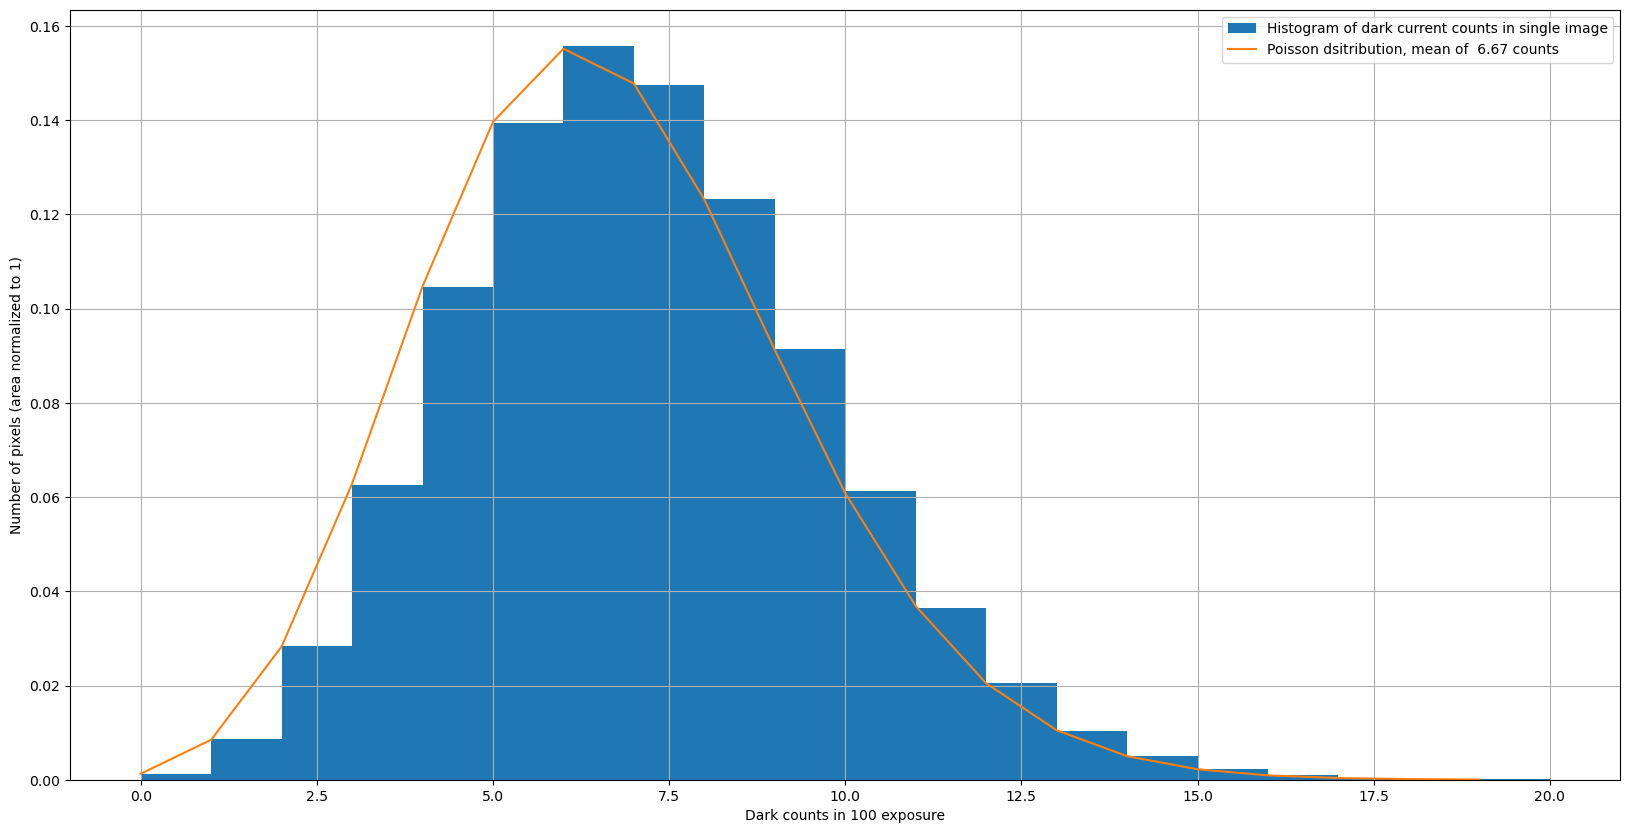

In [14]:
plt.figure(figsize=(20, 10))


h = plt.hist(darks[-1].flatten(), bins=20, align='mid', density=True, 
             label="Histogram of dark current counts in single image");
bins = h[1]
pois = stats.poisson(dark_rate * exposure / gain)
pois_x = np.arange(0, 20, 1)

plt.plot(pois_x, pois.pmf(pois_x), 
         label="Poisson dsitribution, mean of {:5.2f} counts".format(dark_rate * exposure / gain))  

plt.xlabel("Dark counts in {} exposure".format(exposure))
plt.ylabel("Number of pixels (area normalized to 1)")
plt.legend()
plt.grid()

# Illustration with dark current and read noise

Now let’s run through the same couple of plots with a <u>non-zero read noise.</u> For the sake of illustration, we’ll look at two cases:

1. Moderate read noise of $10e^-$ per read, typical of a low-end research-grade CCD
2. Low read noise of $1e^-$ per read

In both cases we’ll continue with the parameters above to generate our frames:

- Dark current is $d_c (T) = 0.1e^-$/pixel/sec
- Gain is $g = 1.5e^-$/ADU
- Ezposure time $100$sec
  
With those choices the expected dark count is 6.67 count, which is $10e^-$. That is, not coincidentally, one of the values for read noise that was chosen.

The dark current rate in this example is somewhat higher than that of a real CCD. A large dark current is used here to demonstrate the interaction of dark current and read noise, and the exposure time has been chosen that expected dark electrons is $10e-$.

## High noise

In this first case, the read noise and the dark current are both $10e^-$. As we will see shortly, the dark frame really measures read noise, not dark current, under these circumstances.

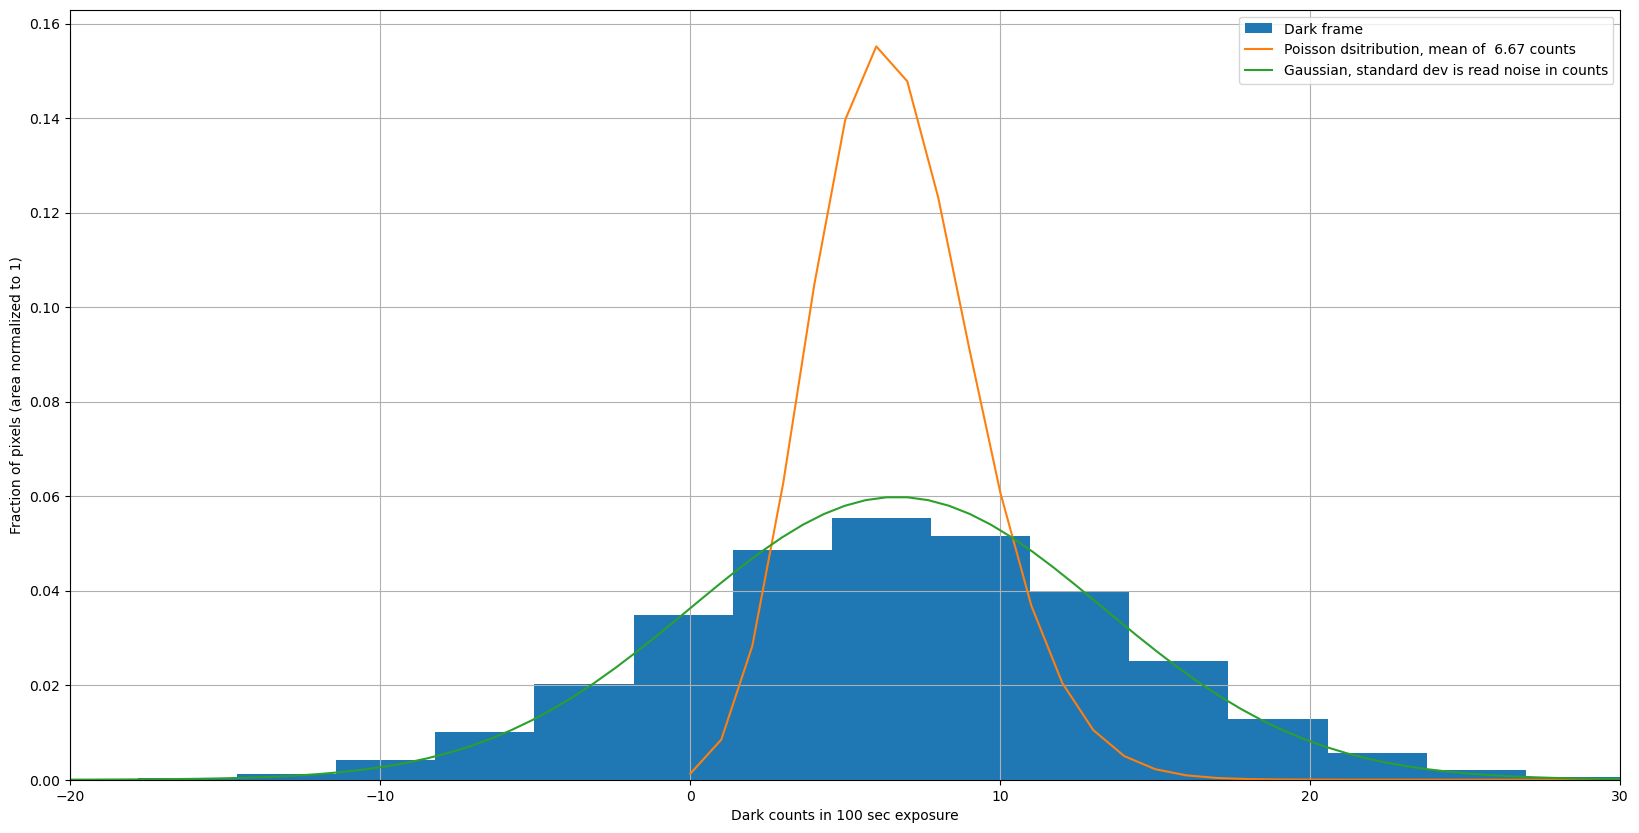

In [15]:
high_read_noise = 10

darks = generate_dark_frames(n_images, 
                             dark_rate=dark_rate, 
                             noise=high_read_noise,
                            gain=gain,
                            exposure=exposure,
                            image_size=image_size)

image_average = darks.mean(axis=0)

plt.figure(figsize=(20,10))
plot_dark_with_distributions(darks[-1],
                            high_read_noise,
                            dark_rate,
                            n_images=1,
                            exposure=exposure,
                            gain=gain)
plt.xlim(-20, 30);

**This dark frame measures noise, not dark current**

The pixel distribution is clearly a <u>Gaussian distribution</u> with a width determined by the read noise, not the underlying Poisson distribution that a dark frame is trying to measure. The only way around this (assuming the dark current is large enough that it needs to be subtracted at all) is to make the exposure long enough that the expected counts exceed the dark current.

We explore that case below by adding in a much smaller amount of noise.

---

**Combining does not recover the dark current**

The plots below show the result of averaging several (20 in this case) dark frames together. We might hope that averaging reduces the noise enough that the distribution of pixels becomes the Poisson distribution expected for a dark frame. It does not.

**Note:** To correctly calculate the expected distribution of counts in the average of the dark frames you should start with the expectations for the sum of the images, then scale counts down by the number of images and the distribution up by the same factor so that the distribution remains normalized.

*A média reduz o tamanho do ruído (diminui o σ da Gaussiana), mas não muda a FORMA da distribuição!*

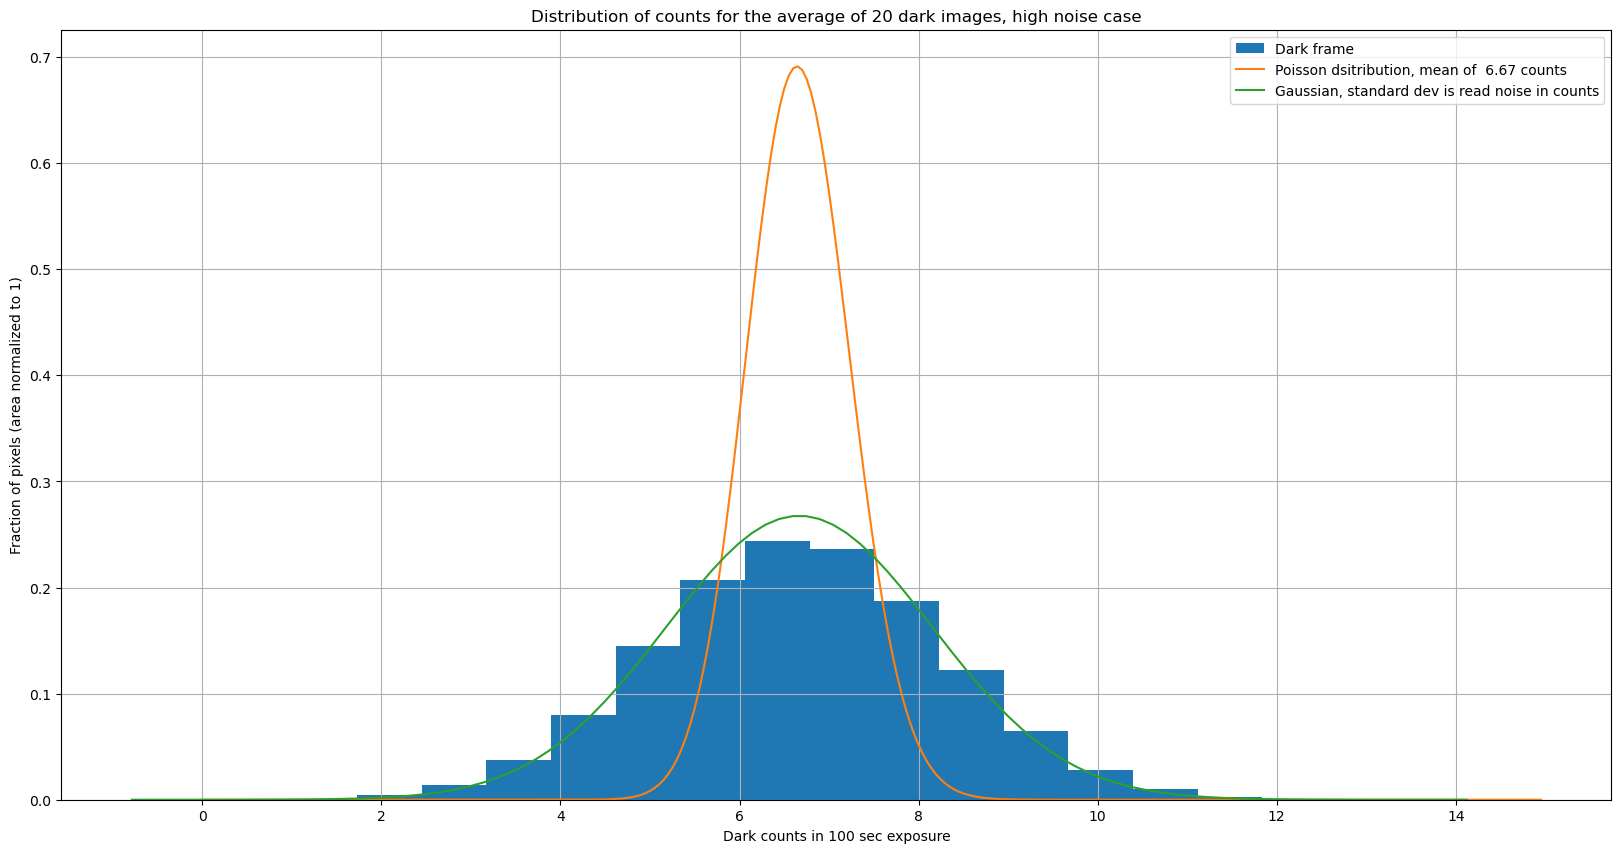

In [16]:
plt.figure(figsize=(20, 10))

plot_dark_with_distributions(image_average, high_read_noise, dark_rate, 
                             n_images=20, exposure=exposure, gain=gain)

plt.title("Distribution of counts for the average of 20 dark images, high noise case");

Even the combination of 20 dark frames doesn’t lead to a Poisson distribution; the distribution is still a Gaussian whose width is determined by the read noise and the number of images.

## Low noise

In this case the read noise is $1e^-$, lower by a factor of ten than the expected dark current for this exposure time, $10e^-$.

<u>This case almost never occurs in real CCDs</u>, but it illustrates that with a low enough read noise you can recover the Poisson distribution of the dark current.

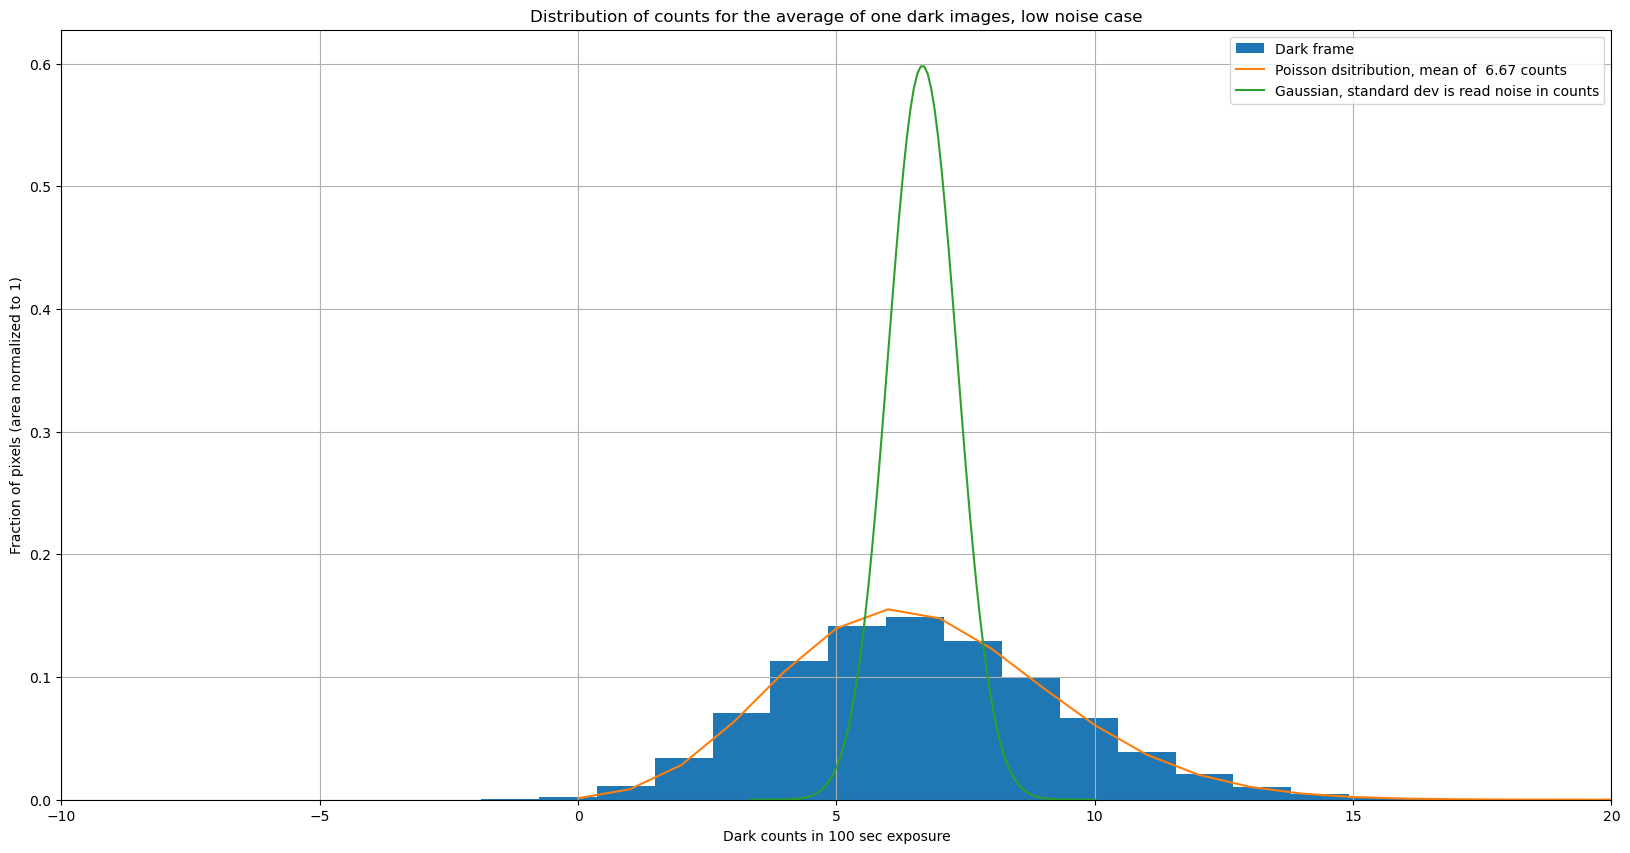

In [17]:
low_read_noise = 1

darks = generate_dark_frames(n_images, dark_rate=dark_rate, noise=low_read_noise, 
                             gain=gain, exposure=exposure, image_size=image_size)

image_average = darks.mean(axis=0)

plt.figure(figsize=(20, 10))


plot_dark_with_distributions(darks[-1], low_read_noise, dark_rate, 
                             n_images=1, exposure=exposure, gain=gain)

#plt.ylim(0, 0.8)
plt.xlim(-10, 20)
plt.title("Distribution of counts for the average of one dark images, low noise case");

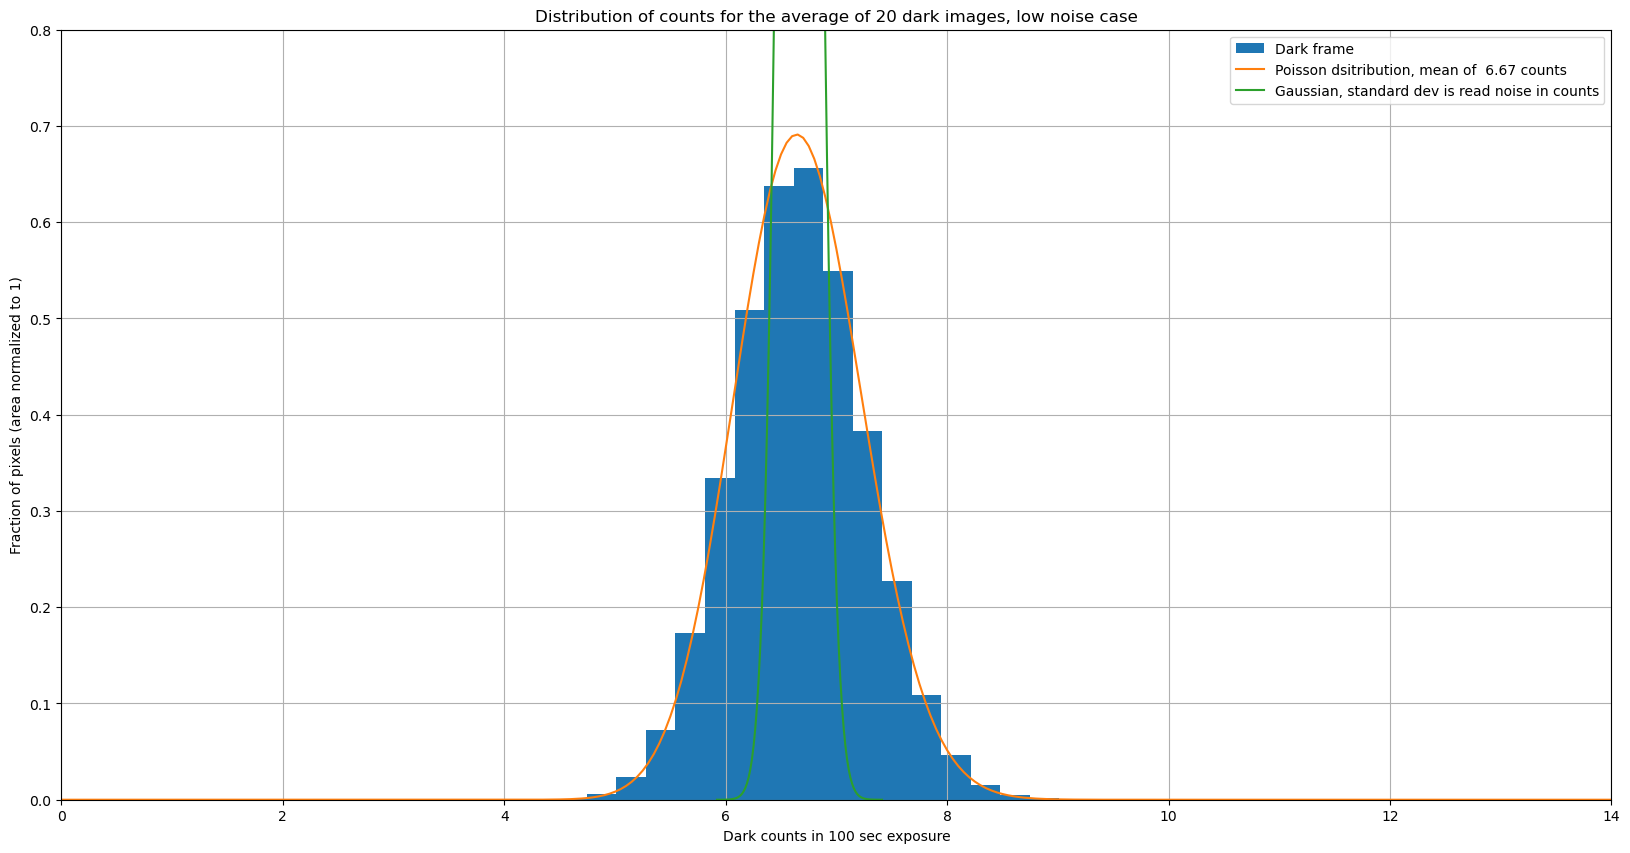

In [18]:
plt.figure(figsize=(20, 10))


plot_dark_with_distributions(image_average, low_read_noise, dark_rate, 
                             n_images=20, exposure=exposure, gain=gain)

plt.ylim(0, 0.8)
plt.xlim(0, 14)
plt.title("Distribution of counts for the average of 20 dark images, low noise case");

**Dark frame is measuring dark current**

Unlike the high noise case, the pixels in a single low-noise dark frame follow the Poisson distribution expected for the dark current in this simulated camera. When multiple images are combined the pixels still follow the Poisson distribution, as expected in this case.

*Isso significa que:*
- *O sinal da dark current é maior que o de read noise*
- *A distribuição dos pixels segue a distribuição de Poisson*
- *Pode medir com precisão a corrente de escuro*
- *Um único dark frame já é representativo do dark current*
- *Este é o cenário ideal para calibração de dados astronômicos*

---

*Na prática, as câmeras astronômicas de alta qualidade são resfriadas (para reduzir o dark current) e têm baixo read noise, aproximando-se deste cenário ideal. Mas em alguns casos (câmeras mais simples ou exposições curtas), pode estar no cenário de "dark frame mede ruído" e precisa tomar cuidado!*

<h1 style="text-align: left; font-family: 'menlo'; color: #e6a3a3; font-size:40px;">
  <span style="background-color: #9b1515; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Notes
  </span>
</h1>

- Dark frame é a soma de: nível de bias da câmera, read noise e dark current.
- Dark current é o sinal gerado termicamente no CCD, proporcional ao tempo de exposição $d_e (t) = d_c(T)t$.
- `plt.xlim()` é uma função que retorna os limites atuais do eixo x do gráfico. Ela retorna uma tupla com dois valores: (x_min, x_max). x_min = onde a linha começa, x_max = onde a linha termina.
- <u>Loop externo</u> é o loop "de fora" que executa menos vezes e controla a iteração principal. <u>Loop interno</u> serio o  loop "de dentro", que executa todas as suas iterações para CADA iteração do loop externo.
    - Nesse código tem o exemplo: loop externo percorre pixels, loop interno percorre imagens PARA CADA pixel.
- Lembrar que:
    - Distribuição Gaussiana é uma forma de descrever como os dados se espalham ao redor de um valor central.
    - <u>Distribuição de Poisson</u> é uma distribuição de probabilidade discreta que modela o número de eventos ocorrendo em um intervalo fixo de tempo, espaço ou volume. Ela é aplicável quando eventos ocorrem independentemente a uma taxa média constante
    - Poisson vira Gaussiana quando a média é grande (flats bem expostos (muitos fótons) podem ser tratados como Gaussianos).

---

<h1 style="text-align: left; font-family: 'menlo'; color: #e6a3a3; font-size:40px;">
  <span style="background-color: #9b1515; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Links
  </span>
</h1>

https://github.com/sh4rkNy/astropy-coisas/tree/main<br>https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/03-01-Dark-current-The-ideal-case.html